# Notebook 02 — Data Loading and First Inspection

## What this notebook does
I download the Montgomery County and Shenzhen CXR datasets, organise them into a unified manifest CSV, and perform the very first inspection: image counts, shapes, file sizes, label distribution, and sample visualisations.

## Why this step matters
Before any model sees data, I need to confirm: Are the files complete? Are images corruptly saved? Is the label distribution as documented? Are there unexpected duplicates?

## What Python / ML concepts I practise
- Downloading files with `requests` and `zipfile`
- Pathlib for file management
- PIL/Pillow for image loading
- Pandas for data manifests
- Matplotlib for sample visualisations

## Input files expected
- Internet access (for download), OR pre-downloaded ZIPs in `data/raw/`

## Output files created
- `data/raw/montgomery/` — raw Montgomery images
- `data/raw/shenzhen/` — raw Shenzhen images
- `data/interim/manifest.csv` — unified image manifest

## How this connects to the main project question
The manifest is the single source of truth for all downstream notebooks. Every preprocessing, split, and training step reads from it.

In [3]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# ── Flag to use mock data (set True for fast testing without real download) ──
USE_MOCK_DATA = False  # ← Change to False when you have real data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import requests, zipfile, io, os
from tqdm import tqdm

from src.config import load_config
from src.paths import get_paths
from src.data_utils import make_mock_dataset
from src.visualization import set_publication_style

cfg   = load_config()
paths = get_paths()
set_publication_style()
print(f"USE_MOCK_DATA = {USE_MOCK_DATA}")
print(f"Raw data directory: {paths['raw']}")

USE_MOCK_DATA = False
Raw data directory: C:\Users\Peter\Documents\projects\Data_science\fedtb_nigeria\data\raw


## Download Instructions (Real Data)

The cells below will download Montgomery and Shenzhen if `USE_MOCK_DATA = False`.

**Montgomery County CXR Set**
- Size: ~115 MB
- Source: US National Library of Medicine
- Direct URL: https://openi.nlm.nih.gov/imgs/collections/NLM-MontgomeryCXRSet.zip

**Shenzhen Hospital CXR Set**
- Size: ~1.2 GB
- Source: NLM Open-i collection
- Direct URL: https://openi.nlm.nih.gov/imgs/collections/ChinaSet_AllFiles.zip

Estimated download time: 10–30 minutes depending on connection speed.
Set `USE_MOCK_DATA = False` to trigger the download.

In [4]:
def download_and_extract(url, dest_dir, dataset_name):
    """Download a ZIP file and extract it to dest_dir."""
    dest_dir = Path(dest_dir)
    dest_dir.mkdir(parents=True, exist_ok=True)

    print(f"Downloading {dataset_name}...")
    print(f"  URL: {url}")
    print(f"  Destination: {dest_dir}")

    response = requests.get(url, stream=True)
    response.raise_for_status()

    total_size = int(response.headers.get("content-length", 0))
    downloaded = 0
    chunks = []

    for chunk in response.iter_content(chunk_size=8192):
        chunks.append(chunk)
        downloaded += len(chunk)
        if total_size > 0:
            pct = 100 * downloaded / total_size
            print(f"  Progress: {pct:.1f}%", end="\r")

    print(f"  Downloaded {downloaded / 1e6:.1f} MB")

    zip_data = b"".join(chunks)
    with zipfile.ZipFile(io.BytesIO(zip_data)) as zf:
        zf.extractall(dest_dir)

    print(f"  Extracted to: {dest_dir}")
    return dest_dir

if not USE_MOCK_DATA:
    # mont_dir = download_and_extract(
    #    url="https://openi.nlm.nih.gov/imgs/collections/NLM-MontgomeryCXRSet.zip",
    #    dest_dir=paths["raw"] / "montgomery",
    #    dataset_name="Montgomery County CXR"
    #)
    shen_dir = download_and_extract(
        url="https://openi.nlm.nih.gov/imgs/collections/ChinaSet_AllFiles.zip",
        dest_dir=paths["raw"] / "shenzhen",
        dataset_name="Shenzhen Hospital CXR"
    )
else:
    print("USE_MOCK_DATA=True — skipping download, generating mock dataset instead.")
    mock_df = make_mock_dataset(
        save_dir=paths["mock"],
        num_images=60,
        image_size=64,
        seed=cfg["project"]["random_seed"],
    )
    print(mock_df.head())

  URL: https://openi.nlm.nih.gov/imgs/collections/ChinaSet_AllFiles.zip
  Destination: C:\Users\Peter\Documents\projects\Data_science\fedtb_nigeria\data\raw\shenzhen
  Downloaded 3770.2 MB
  Extracted to: C:\Users\Peter\Documents\projects\Data_science\fedtb_nigeria\data\raw\shenzhen


I already downloaded the Montgomery County CXR dataset, that was why I commented it while reruning the code cell to download the second dataset.

## Build Unified Manifest

I parse the Montgomery and Shenzhen filename conventions to extract labels:
- Montgomery: filenames contain `_0` (normal) or `_1` (TB positive)
- Shenzhen: similarly encoded; see NLM documentation

In [5]:
def parse_montgomery(mont_dir):
    """Parse Montgomery CXR directory into a DataFrame."""
    mont_dir = Path(mont_dir)
    # Montgomery stores images in MontgomerySet/CXR_png/
    # Labels are in MontgomerySet/ClinicalReadings/ text files
    # Simpler approach: filename convention — MCUCXR_XXXX_0.png = normal, _1.png = TB

    image_dir = mont_dir / "MontgomerySet" / "CXR_png"
    if not image_dir.exists():
        # Fallback: search recursively for PNGs
        image_dir = mont_dir

    records = []
    for f in sorted(image_dir.rglob("*.png")):
        fname = f.stem  # e.g., MCUCXR_0001_0
        # Last character before extension indicates label
        try:
            label = int(fname.split("_")[-1])
        except ValueError:
            label = -1  # Unknown

        records.append({
            "image_path": str(f.resolve()),
            "label": label,
            "dataset": "montgomery",
            "original_filename": f.name,
        })
    return pd.DataFrame(records)

def parse_shenzhen(shen_dir):
    """Parse Shenzhen CXR directory into a DataFrame."""
    shen_dir = Path(shen_dir)
    # Shenzhen: CHNCXR_XXXX_0.png = normal, CHNCXR_XXXX_1.png = TB

    image_dir = shen_dir / "ChinaSet_AllFiles" / "ChinaSet_AllFiles" / "CXR_png"
    if not image_dir.exists():
        image_dir = shen_dir

    records = []
    for f in sorted(image_dir.rglob("*.png")):
        fname = f.stem
        try:
            label = int(fname.split("_")[-1])
        except ValueError:
            label = -1

        records.append({
            "image_path": str(f.resolve()),
            "label": label,
            "dataset": "shenzhen",
            "original_filename": f.name,
        })
    return pd.DataFrame(records)

if USE_MOCK_DATA:
    manifest = make_mock_dataset(paths["mock"], num_images=60, seed=42)
    manifest["split"] = "unassigned"
else:
    df_mont = parse_montgomery(paths["raw"] / "montgomery")
    df_shen = parse_shenzhen(paths["raw"] / "shenzhen")
    manifest = pd.concat([df_mont, df_shen], ignore_index=True)
    manifest = manifest[manifest["label"].isin([0, 1])].reset_index(drop=True)

print(f"Total images in manifest: {len(manifest)}")
print(f"Label distribution:")
print(manifest["label"].value_counts())
print()
print(manifest.head(8))

Total images in manifest: 800
Label distribution:
label
0    406
1    394
Name: count, dtype: int64

                                          image_path  label     dataset  \
0  C:\Users\Peter\Documents\projects\Data_science...      0  montgomery   
1  C:\Users\Peter\Documents\projects\Data_science...      0  montgomery   
2  C:\Users\Peter\Documents\projects\Data_science...      0  montgomery   
3  C:\Users\Peter\Documents\projects\Data_science...      0  montgomery   
4  C:\Users\Peter\Documents\projects\Data_science...      0  montgomery   
5  C:\Users\Peter\Documents\projects\Data_science...      0  montgomery   
6  C:\Users\Peter\Documents\projects\Data_science...      0  montgomery   
7  C:\Users\Peter\Documents\projects\Data_science...      0  montgomery   

   original_filename  
0  MCUCXR_0001_0.png  
1  MCUCXR_0002_0.png  
2  MCUCXR_0003_0.png  
3  MCUCXR_0004_0.png  
4  MCUCXR_0005_0.png  
5  MCUCXR_0006_0.png  
6  MCUCXR_0008_0.png  
7  MCUCXR_0011_0.png  


In [6]:
# Save the manifest to interim/
manifest_path = paths["interim"] / "manifest.csv"
manifest.to_csv(manifest_path, index=False)
print(f"Manifest saved: {manifest_path}")
print(f"Shape: {manifest.shape}")

Manifest saved: C:\Users\Peter\Documents\projects\Data_science\fedtb_nigeria\data\interim\manifest.csv
Shape: (800, 4)


## Sample Image Visualisation

I visualise a random sample of TB-positive and TB-negative images.
This is an important sanity check: do the images look like chest X-rays?
Are labels plausible?

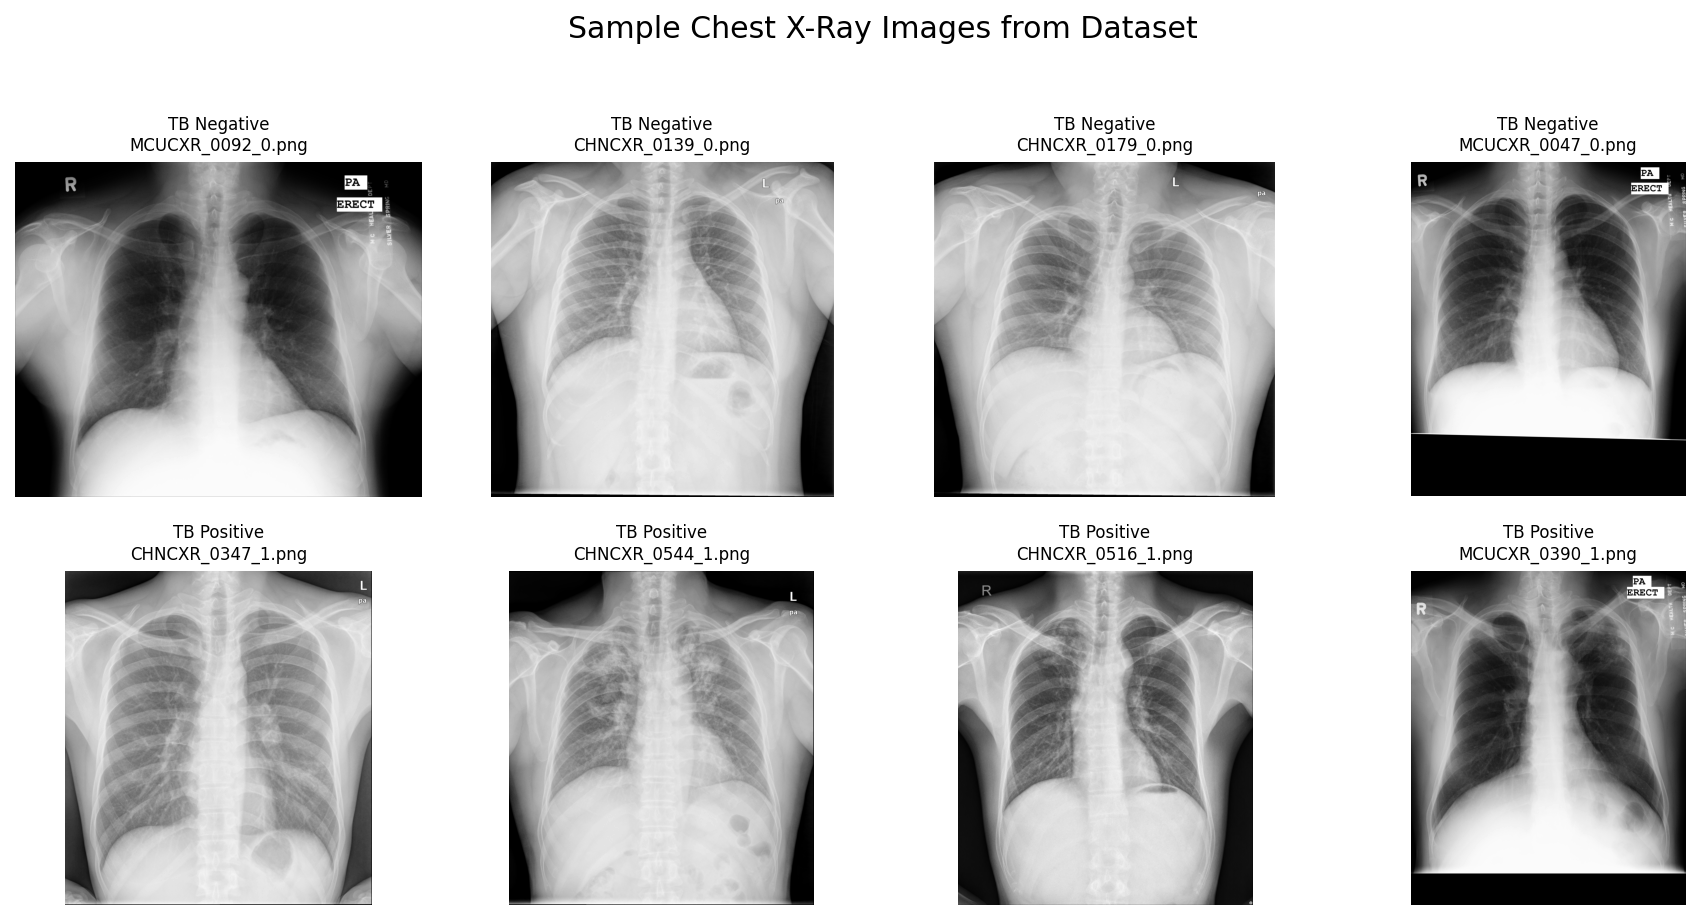

Figure saved: sample_images.png


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for row_idx, label in enumerate([0, 1]):
    label_name = "TB Negative" if label == 0 else "TB Positive"
    subset = manifest[manifest["label"] == label].sample(
        n=min(4, len(manifest[manifest["label"] == label])),
        random_state=42
    )

    for col_idx, (_, row) in enumerate(subset.iterrows()):
        ax = axes[row_idx, col_idx]
        img = Image.open(row["image_path"]).convert("L")  # Greyscale
        ax.imshow(img, cmap="gray")
        ax.set_title(f"{label_name}\n{Path(row['image_path']).name[:20]}", fontsize=8)
        ax.axis("off")

# If fewer than 4 per class, blank remaining axes
for row_idx in range(2):
    label = row_idx
    subset = manifest[manifest["label"] == label]
    for col_idx in range(min(4, len(subset)), 4):
        axes[row_idx, col_idx].axis("off")

plt.suptitle("Sample Chest X-Ray Images from Dataset", y=1.02)
plt.tight_layout()
fig.savefig(paths["figures"] / "sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: sample_images.png")

## Image Shape and File Size Checks

In [9]:
# Check a sample of images for shape and size consistency
sample_n = min(20, len(manifest))
sample_df = manifest.sample(n=sample_n, random_state=42)

shapes = []
filesizes_kb = []

for _, row in sample_df.iterrows():
    img = Image.open(row["image_path"])
    shapes.append(img.size)   # (width, height)
    filesizes_kb.append(Path(row["image_path"]).stat().st_size / 1024)

widths  = [s[0] for s in shapes]
heights = [s[1] for s in shapes]

print(f"Image shape summary (sample of {sample_n}):")
print(f"  Width  — min: {min(widths)}, max: {max(widths)}, mean: {sum(widths)/len(widths):.0f}")
print(f"  Height — min: {min(heights)}, max: {max(heights)}, mean: {sum(heights)/len(heights):.0f}")
print()
print(f"File size summary (KB):")
print(f"  Min: {min(filesizes_kb):.1f} KB")
print(f"  Max: {max(filesizes_kb):.1f} KB")
print(f"  Mean: {sum(filesizes_kb)/len(filesizes_kb):.1f} KB")
print()
print("I will resize all images to 224×224 during preprocessing (Notebook 05).")
print("This is the standard input size for ResNet-18.")

Image shape summary (sample of 20):
  Width  — min: 2238, max: 4892, mean: 3076
  Height — min: 2317, max: 4892, mean: 3164

File size summary (KB):
  Min: 3546.5 KB
  Max: 6507.3 KB
  Mean: 5458.9 KB

I will resize all images to 224×224 during preprocessing (Notebook 05).
This is the standard input size for ResNet-18.
